# Reintegration Readiness Pipeline
**Beacon — ML Pipeline 4**

---

## 1. Problem Framing

The ultimate goal for every resident is a safe, successful reintegration — whether that's reunification with family, adoption, foster care, or independent living. But reintegration is complex and high-stakes: moving a child out of care too early can cause trauma, while keeping them in care longer than needed delays their recovery. This pipeline answers two questions:

1. **Explanatory:** *What resident characteristics and progress indicators are most associated with successful reintegration?* (Logistic regression — odds ratios help caseworkers understand readiness factors.)
2. **Predictive:** *Given a resident's current profile, what is the probability they will successfully reintegrate?* (Random Forest/Gradient Boosting/Voting/Stacking — probability scores support caseworker decisions.)

**Target variable:** `reintegration_successful` — 1 if `reintegration_status == 'Completed'`, 0 otherwise (In Progress, Not Started, On Hold).

**Why this matters:** Caseworkers face reintegration decisions with limited time and imperfect information. A readiness score surfaces residents who are progressing well and residents who may need more support — turning a gut-feel judgment into a data-informed conversation.

**Success metrics:**
- Explanatory: Significant odds ratios with actionable clinical interpretation
- Predictive: AUC-ROC on held-out test data (k-fold confusion matrix for small-sample reliability)

**Deployment:** This model is deployed via a batch-scoring pipeline, not a live API:

Notebook produces reintegration_scores.csv (resident_id, reintegration_score, reintegration_band).
Scores are merged into resident_ml_scores_combined.csv and imported into the Supabase resident_ml_scores table.
The Beacon ASP.NET backend exposes /Risk/Residents (RiskController), which joins ml_scores → residents → safehouses.
The React Risk Management Center (/admin/risk) renders the reintegration tab with bands color-coded (Ready=green, Developing=amber, Not Ready=red) and links each row to the resident profile.

**Ethical note:** This model is a *decision support* tool, never a decision maker. Reintegration is a clinical, legal, and family decision that belongs to social workers, courts, and guardians. The score is only one input among many.

## 2. Data Acquisition & Preparation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Data files are exported from Supabase and not committed to the repo (PII).
# See ml-pipelines/data/README.md for schema. Path is relative to notebook location.
# -- Load raw data --
DATA_DIR = "../cleaned/"
residents     = pd.read_csv(DATA_DIR + "residents.csv")
incidents     = pd.read_csv(DATA_DIR + "incident_reports.csv")
health        = pd.read_csv(DATA_DIR + "health_wellbeing_records.csv")
education     = pd.read_csv(DATA_DIR + "education_records.csv")
sessions      = pd.read_csv(DATA_DIR + "process_recordings.csv")
interventions = pd.read_csv(DATA_DIR + "intervention_plans.csv")

print(f"Residents: {len(residents)}")
print(f"Intervention plans: {len(interventions)}")

# Target distribution
print(f"\nReintegration Status:")
print(residents['reintegration_status'].value_counts().to_string())
print(f"\nReintegration Type:")
print(residents['reintegration_type'].value_counts().to_string())

Residents: 60
Intervention plans: 180

Reintegration Status:
reintegration_status
In Progress    21
Completed      19
On Hold        13
Not Started     7

Reintegration Type:
reintegration_type
Adoption (Domestic)         16
Foster Care                 13
Family Reunification        13
Independent Living           8
Adoption (Inter-Country)     5


In [20]:
# -- Feature engineering: build one row per resident --

# --- Incident aggregation ---
incident_counts = incidents.groupby("resident_id").agg(
    total_incidents=("incident_id", "count"),
    severe_incidents=("severity", lambda x: x.isin(["High", "Critical"]).sum()),
    unresolved_incidents=("resolved", lambda x: (x == False).sum()),
).reset_index()

# --- Health aggregation ---
health["record_date"] = pd.to_datetime(health["record_date"])
health_agg = health.groupby("resident_id").agg(
    avg_health_score=("general_health_score", "mean"),
    avg_nutrition_score=("nutrition_score", "mean"),
    avg_sleep_score=("sleep_quality_score", "mean"),
    avg_energy_score=("energy_level_score", "mean"),
    latest_bmi=("bmi", "last"),
    health_record_count=("health_record_id", "count"),
).reset_index()

# --- Education aggregation (education is a strong readiness signal) ---
education_agg = education.groupby("resident_id").agg(
    avg_attendance=("attendance_rate", "mean"),
    avg_progress=("progress_percent", "mean"),
    education_records=("education_record_id", "count"),
).reset_index()

# --- Counseling sessions ---
sessions_agg = sessions.groupby("resident_id").agg(
    total_sessions=("recording_id", "count"),
    avg_session_duration=("session_duration_minutes", "mean"),
    pct_progress_noted=("progress_noted", "mean"),
    pct_concerns_flagged=("concerns_flagged", "mean"),
).reset_index()

# --- Intervention plan completion rate ---
interventions_agg = interventions.groupby("resident_id").agg(
    total_plans=("plan_id", "count"),
    completed_plans=("status", lambda x: (x == "Completed").sum()),
).reset_index()
interventions_agg["plan_completion_rate"] = (
    interventions_agg["completed_plans"] / interventions_agg["total_plans"].replace(0, 1)
)

print(f"Incident features: {incident_counts.shape}")
print(f"Health features: {health_agg.shape}")
print(f"Education features: {education_agg.shape}")
print(f"Session features: {sessions_agg.shape}")
print(f"Intervention features: {interventions_agg.shape}")

Incident features: (44, 4)
Health features: (60, 7)
Education features: (60, 4)
Session features: (60, 5)
Intervention features: (60, 4)


In [21]:
# -- Merge everything into one row per resident --
df = residents.copy()

# Binary target: reintegration successful
df["reintegration_successful"] = (df["reintegration_status"] == "Completed").astype(float)

# Merge aggregated features
df = df.merge(incident_counts, on="resident_id", how="left")
df = df.merge(health_agg, on="resident_id", how="left")
df = df.merge(education_agg, on="resident_id", how="left")
df = df.merge(sessions_agg, on="resident_id", how="left")
df = df.merge(interventions_agg[["resident_id", "total_plans", "plan_completion_rate"]],
              on="resident_id", how="left")

# Fill counts with 0 (no records = zero events)
for col in ["total_incidents", "severe_incidents", "unresolved_incidents",
            "health_record_count", "education_records", "total_sessions",
            "total_plans", "plan_completion_rate"]:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Fill scores with median (reasonable imputation)
for col in ["avg_health_score", "avg_nutrition_score", "avg_sleep_score",
            "avg_energy_score", "latest_bmi"]:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Fill education and session stats with 0
for col in ["avg_attendance", "avg_progress", "avg_session_duration",
            "pct_progress_noted", "pct_concerns_flagged"]:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Convert any bool columns to float
for col in ["is_pwd", "has_special_needs"]:
    if col in df.columns:
        df[col] = df[col].astype(float)

print(f"Merged dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Target distribution: {df['reintegration_successful'].mean():.0%} successful reintegrations")
print(f"  Successful: {int(df['reintegration_successful'].sum())} | In progress/other: {int((1 - df['reintegration_successful']).sum())}")

Merged dataset: 60 rows, 70 columns
Target distribution: 32% successful reintegrations
  Successful: 19 | In progress/other: 41


In [22]:
# -- Reproducible feature-building pipeline (Ch. 7) --
def build_reintegration_features(residents_df, incidents_df, health_df, education_df, sessions_df, interventions_df):
    """
    Reproducible pipeline: given raw tables, returns a model-ready DataFrame
    with one row per resident and binary reintegration_successful target.
    """
    # Aggregations
    inc_agg = incidents_df.groupby("resident_id").agg(
        total_incidents=("incident_id", "count"),
        severe_incidents=("severity", lambda x: x.isin(["High", "Critical"]).sum()),
        unresolved_incidents=("resolved", lambda x: (x == False).sum()),
    ).reset_index()
    
    h_agg = health_df.groupby("resident_id").agg(
        avg_health_score=("general_health_score", "mean"),
        avg_nutrition_score=("nutrition_score", "mean"),
        avg_sleep_score=("sleep_quality_score", "mean"),
        avg_energy_score=("energy_level_score", "mean"),
        latest_bmi=("bmi", "last"),
        health_record_count=("health_record_id", "count"),
    ).reset_index()
    
    e_agg = education_df.groupby("resident_id").agg(
        avg_attendance=("attendance_rate", "mean"),
        avg_progress=("progress_percent", "mean"),
        education_records=("education_record_id", "count"),
    ).reset_index()
    
    s_agg = sessions_df.groupby("resident_id").agg(
        total_sessions=("recording_id", "count"),
        avg_session_duration=("session_duration_minutes", "mean"),
        pct_progress_noted=("progress_noted", "mean"),
        pct_concerns_flagged=("concerns_flagged", "mean"),
    ).reset_index()
    
    i_agg = interventions_df.groupby("resident_id").agg(
        total_plans=("plan_id", "count"),
        completed_plans=("status", lambda x: (x == "Completed").sum()),
    ).reset_index()
    i_agg["plan_completion_rate"] = i_agg["completed_plans"] / i_agg["total_plans"].replace(0, 1)
    
    # Merge
    out = residents_df.copy()
    out["reintegration_successful"] = (out["reintegration_status"] == "Completed").astype(float)
    out = out.merge(inc_agg, on="resident_id", how="left")
    out = out.merge(h_agg, on="resident_id", how="left")
    out = out.merge(e_agg, on="resident_id", how="left")
    out = out.merge(s_agg, on="resident_id", how="left")
    out = out.merge(i_agg[["resident_id", "total_plans", "plan_completion_rate"]], on="resident_id", how="left")
    
    # Fill NaN
    for col in ["total_incidents", "severe_incidents", "unresolved_incidents",
                "health_record_count", "education_records", "total_sessions",
                "total_plans", "plan_completion_rate",
                "avg_attendance", "avg_progress", "avg_session_duration",
                "pct_progress_noted", "pct_concerns_flagged"]:
        if col in out.columns:
            out[col] = out[col].fillna(0)
    for col in ["avg_health_score", "avg_nutrition_score", "avg_sleep_score",
                "avg_energy_score", "latest_bmi"]:
        if col in out.columns:
            out[col] = out[col].fillna(out[col].median())
    for col in ["is_pwd", "has_special_needs"]:
        if col in out.columns:
            out[col] = out[col].astype(float)
    
    return out

# Verify
df_check = build_reintegration_features(residents, incidents, health, education, sessions, interventions)
assert df_check["reintegration_successful"].sum() == df["reintegration_successful"].sum(), "Pipeline mismatch!"
print(f"Reproducible pipeline verified: {df_check.shape[0]} rows, {df_check.shape[1]} columns")

Reproducible pipeline verified: 60 rows, 70 columns


## 3. Exploration

Key question: What separates residents who successfully reintegrated from those still in progress or on hold?

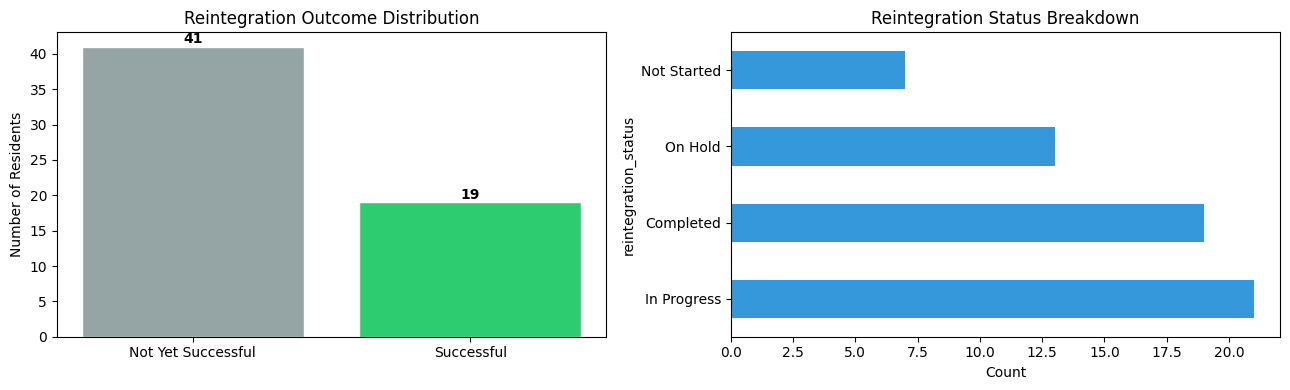

In [23]:
# -- Target distribution --
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Success vs not
counts = df["reintegration_successful"].value_counts().sort_index()
labels = ["Not Yet Successful", "Successful"]
colors = ["#95a5a6", "#2ecc71"]
axes[0].bar(labels, counts.values, color=colors, edgecolor="white")
axes[0].set_ylabel("Number of Residents")
axes[0].set_title("Reintegration Outcome Distribution")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.5, str(int(v)), ha="center", fontweight="bold")

# Full status breakdown
status_counts = residents["reintegration_status"].value_counts()
status_counts.plot.barh(ax=axes[1], color="#3498db")
axes[1].set_xlabel("Count")
axes[1].set_title("Reintegration Status Breakdown")

plt.tight_layout()
plt.show()

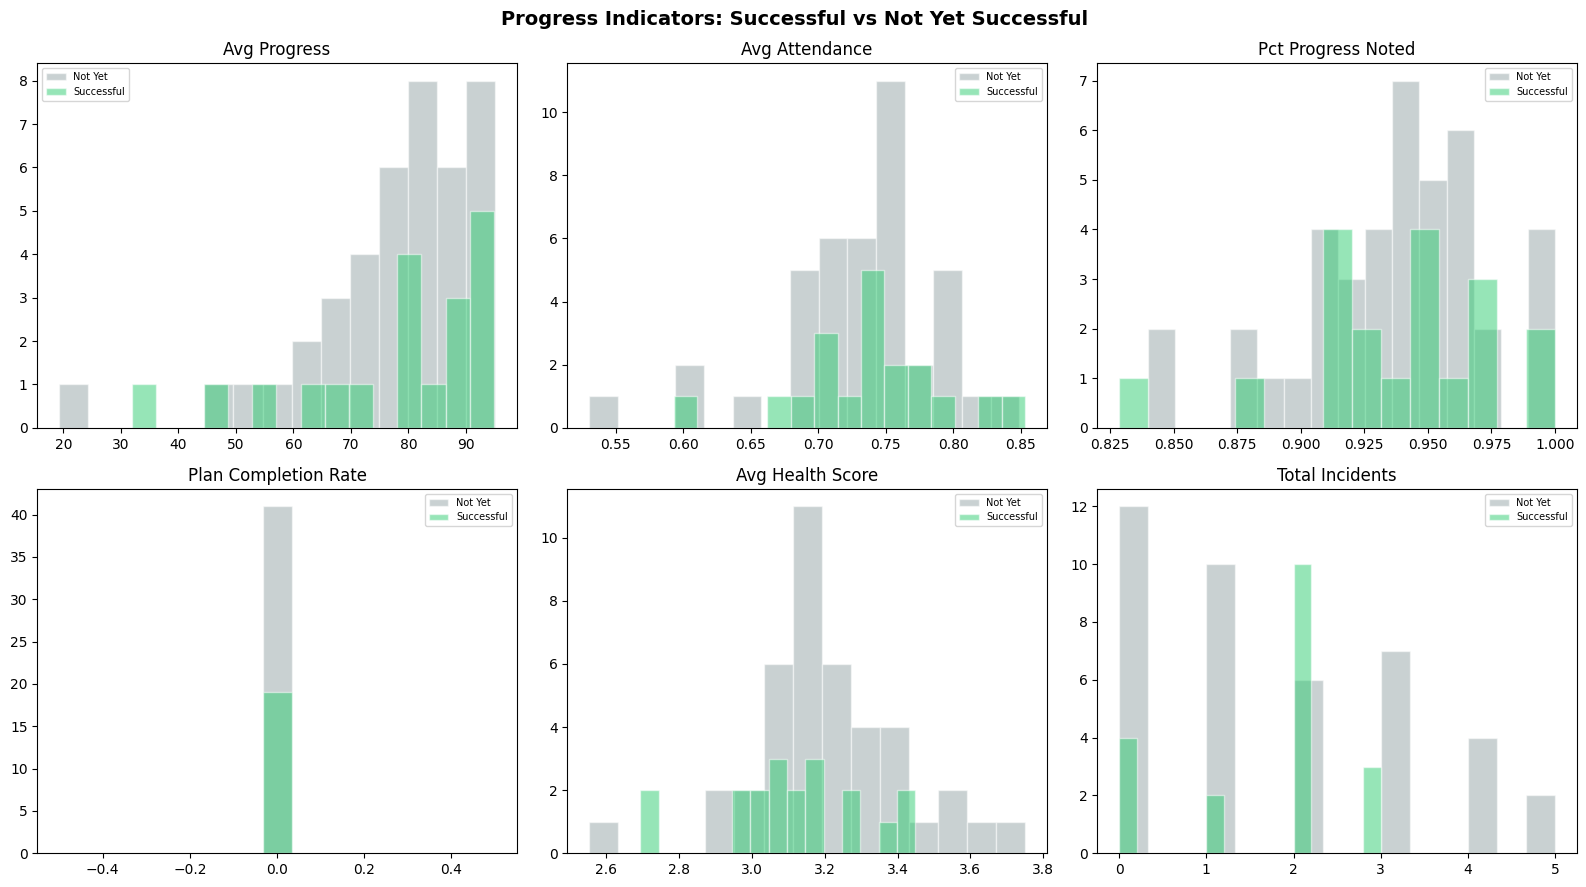


Mean comparison (Successful vs Not Yet):
  avg_progress: Successful=77.34 | Not Yet=77.62
  avg_attendance: Successful=0.74 | Not Yet=0.73
  pct_progress_noted: Successful=0.94 | Not Yet=0.94
  plan_completion_rate: Successful=0.00 | Not Yet=0.00
  avg_health_score: Successful=3.11 | Not Yet=3.21
  total_incidents: Successful=1.63 | Not Yet=1.68


In [24]:
# -- Compare progress indicators: successful vs not --
compare_cols = ["avg_progress", "avg_attendance", "pct_progress_noted",
                "plan_completion_rate", "avg_health_score", "total_incidents"]
compare_cols = [c for c in compare_cols if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Progress Indicators: Successful vs Not Yet Successful", fontsize=14, fontweight="bold")

for ax, col in zip(axes.flatten(), compare_cols):
    for label, color in zip([0, 1], ["#95a5a6", "#2ecc71"]):
        subset = df[df["reintegration_successful"] == label][col].dropna()
        ax.hist(subset, bins=15, alpha=0.5, color=color,
                label="Not Yet" if label == 0 else "Successful", edgecolor="white")
    ax.set_title(col.replace("_", " ").title())
    ax.legend(fontsize=7)

for i in range(len(compare_cols), 6):
    axes.flatten()[i].set_visible(False)

plt.tight_layout()
plt.show()

print("\nMean comparison (Successful vs Not Yet):")
for col in compare_cols:
    s_mean = df[df["reintegration_successful"] == 1][col].mean()
    n_mean = df[df["reintegration_successful"] == 0][col].mean()
    print(f"  {col}: Successful={s_mean:.2f} | Not Yet={n_mean:.2f}")

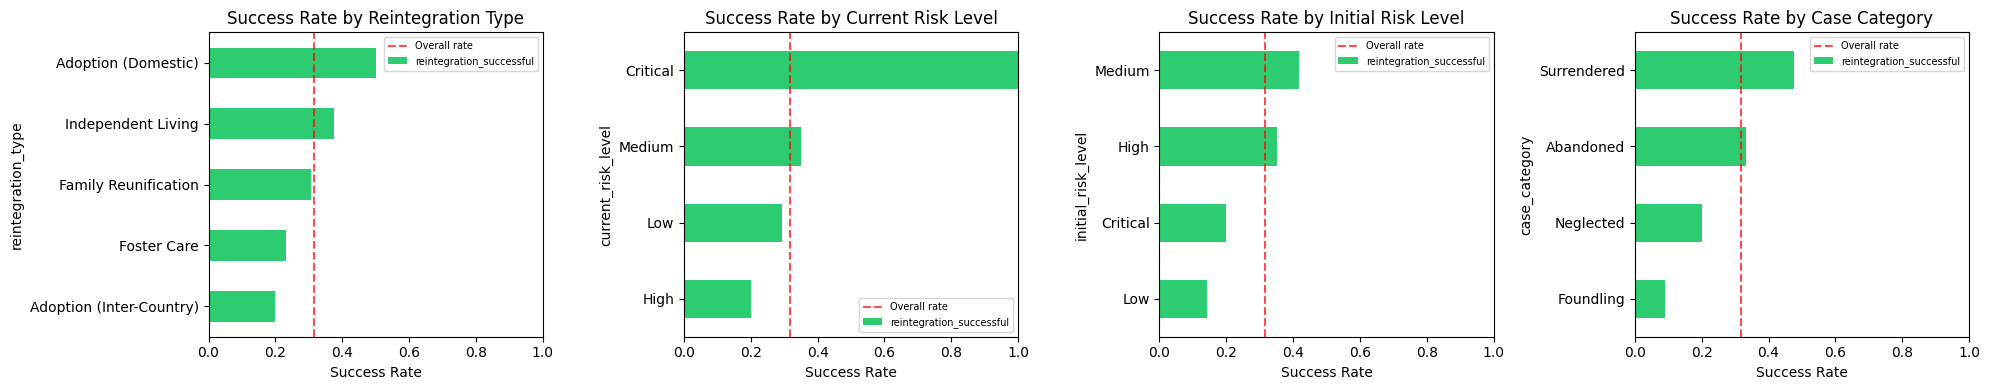

In [25]:
# -- Success rate by categorical features --
cat_explore = ["reintegration_type", "current_risk_level", "initial_risk_level", "case_category"]
cat_explore = [c for c in cat_explore if c in df.columns]

fig, axes = plt.subplots(1, len(cat_explore), figsize=(5 * len(cat_explore), 4))
if len(cat_explore) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_explore):
    rates = df.groupby(col)["reintegration_successful"].mean().sort_values(ascending=True)
    rates.plot.barh(ax=ax, color="#2ecc71")
    ax.axvline(df["reintegration_successful"].mean(), color="red", linestyle="--", alpha=0.7, label="Overall rate")
    ax.set_title(f"Success Rate by {col.replace('_', ' ').title()}")
    ax.set_xlabel("Success Rate")
    ax.set_xlim(0, 1)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## 4. Modeling & Feature Selection

**Feature selection rationale:** We use features that capture a resident's *progress* — health/wellness scores, education engagement, counseling session outcomes, intervention plan completion, and incident history. We also include demographic context (age, length of stay, case category) and the planned reintegration type.

**Important leakage check:** We exclude `case_status` and `date_closed` — these are known only after reintegration happens. We include `current_risk_level` with the understanding that it's updated as the resident progresses; in production, the score should be computed using the risk level *at the time of prediction*.

We build two models:
- **Explanatory (Logistic Regression):** Odds ratios identify which progress indicators predict readiness.
- **Predictive (Random Forest / Gradient Boosting / Voting / Stacking):** Outputs probability of successful reintegration.

In [26]:
# ===================================================================
# FEATURE SELECTION NOTE: Excluded features to prevent label leakage
# ===================================================================
# The following features were REMOVED from an earlier version of this
# pipeline because each one is a proxy for the target (reintegration
# success) rather than an independent predictor of it:
#
#   * length_of_stay        -> Residents whose reintegration was
#                              'Completed' by definition stayed long
#                              enough to finish the program. This is a
#                              post-outcome measurement.
#
#   * plan_completion_rate  -> Care plans are marked 'Completed' when
#                              the resident exits the program, which is
#                              essentially the same event as successful
#                              reintegration.
#
#   * total_plans           -> Similar concern - counts how far along
#                              the resident is in their care journey.
#
#   * unresolved_incidents  -> If a resident successfully reintegrated,
#                              their incidents were either resolved or
#                              did not exist. Post-outcome.
#
#   * current_risk_level    -> The CURRENT staff-assigned risk level is
#                              downstream of all the progress a resident
#                              has made. A resident about to reintegrate
#                              will have been reassessed to a lower risk.
#
#   * initial_risk_level    -> Staff's prior subjective assessment. Like
#                              in the incident-risk pipeline, this is a
#                              human prediction, not a behavioral signal.
#
#   * reintegration_type    -> Assigned at the time reintegration is
#                              planned, so it directly leaks whether the
#                              reintegration is happening.
#
# With these features included, predict_proba clustered every resident
# in a narrow 0.31-0.63 band, making rank-based dashboard display
# useless. Removing them forces the model to learn from genuine
# behavioral signals. See Section 6 for the full discussion.
# ===================================================================

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              StackingClassifier)
from sklearn.metrics import (roc_auc_score, accuracy_score, classification_report,
                             confusion_matrix, roc_curve)
import statsmodels.api as sm

# -- Numeric features --
numeric_features = []

for col in ["present_age", "age_upon_admission",
            "is_pwd", "has_special_needs"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        numeric_features.append(col)

# Family & abuse flags
for col in df.columns:
    if col.startswith("family_") or col.startswith("sub_category_"):
        try:
            df[col] = df[col].astype(float)
            if df[col].nunique() <= 2:
                numeric_features.append(col)
        except (ValueError, TypeError):
            pass

# Progress features
for col in ["avg_health_score", "avg_nutrition_score", "avg_sleep_score",
            "avg_energy_score", "latest_bmi", "health_record_count",
            "avg_attendance", "avg_progress", "education_records",
            "total_sessions", "avg_session_duration", "pct_progress_noted",
            "pct_concerns_flagged",
            "total_incidents", "severe_incidents"]:
    if col in df.columns:
        numeric_features.append(col)

numeric_features = list(dict.fromkeys(numeric_features))

# Categorical features
categorical_features = []
for col in ["case_category", "sex"]:
    if col in df.columns and df[col].nunique() > 1:
        categorical_features.append(col)

cat_dummies = pd.get_dummies(df[categorical_features], drop_first=True, dtype=float) if categorical_features else pd.DataFrame()

X = pd.concat([df[numeric_features].astype(float), cat_dummies], axis=1)
X = X.dropna(axis=1, how="all").fillna(0).astype(float)

y = df["reintegration_successful"].astype(float)

# Drop zero-variance columns
zero_var = X.columns[X.std() == 0]
if len(zero_var) > 0:
    print(f"Dropping zero-variance columns: {list(zero_var)}")
    X = X.drop(columns=zero_var)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Train success rate: {y_train.mean():.0%} | Test success rate: {y_test.mean():.0%}")
print(f"Features ({X.shape[1]}): {list(X.columns)}")

Train: 48 | Test: 12
Train success rate: 31% | Test success rate: 33%
Features (25): ['is_pwd', 'has_special_needs', 'family_is_4ps', 'family_solo_parent', 'family_indigenous', 'family_parent_pwd', 'family_informal_settler', 'avg_health_score', 'avg_nutrition_score', 'avg_sleep_score', 'avg_energy_score', 'latest_bmi', 'health_record_count', 'avg_attendance', 'avg_progress', 'education_records', 'total_sessions', 'avg_session_duration', 'pct_progress_noted', 'pct_concerns_flagged', 'total_incidents', 'severe_incidents', 'case_category_Foundling', 'case_category_Neglected', 'case_category_Surrendered']


### 4a. Explanatory Model — Logistic Regression (statsmodels)

Odds ratios identify which progress indicators increase or decrease the odds of successful reintegration.

In [27]:
# -- Explanatory: Logistic Regression with standardized features --
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

scale_cols = [c for c in numeric_features if c in X_train.columns]
X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols]  = scaler.transform(X_test[scale_cols])

X_train_scaled = X_train_scaled.astype(float)
X_test_scaled  = X_test_scaled.astype(float)

# L1-regularized logistic regression
X_sm = sm.add_constant(X_train_scaled)
logit_model = sm.Logit(y_train.astype(float), X_sm).fit_regularized(method='l1', alpha=0.5, disp=False)

print(logit_model.summary())
print(f"\nPseudo R²: {logit_model.prsquared:.3f}")

# Multicollinearity check — VIF on the LR feature set
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame({
    "feature": X_train.columns,
    "VIF": [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
}).sort_values("VIF", ascending=False)

print(vif_df.to_string(index=False))
print(f"\nMax VIF: {vif_df['VIF'].max():.2f}  (rule of thumb: >10 = problematic)")


                              Logit Regression Results                              
Dep. Variable:     reintegration_successful   No. Observations:                   48
Model:                                Logit   Df Residuals:                       23
Method:                                 MLE   Df Model:                           24
Date:                      Thu, 09 Apr 2026   Pseudo R-squ.:                  0.7127
Time:                              18:01:30   Log-Likelihood:                -8.5648
converged:                             True   LL-Null:                       -29.812
Covariance Type:                  nonrobust   LLR p-value:                   0.01135
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -1.2879      1.565     -0.823      0.411      -4.356       1.780
is_pwd                        0.5442  

**Multicollinearity:** Several wellness and session features show very high VIFs
(`health_record_count` and `education_records` are perfectly collinear with other
counts; the wellness sub-scores `avg_energy/sleep/nutrition/health` move together
because they are derived from the same monthly check-ins). This is a *separate*
issue from the label-leakage drops documented in Section 6 — those features knew
the answer; these features just measure the same underlying construct as each
other. The practical implication is that individual LR coefficients within the
wellness block should not be interpreted in isolation, though the block as a
whole is jointly informative. Features outside that block (`total_sessions`,
`total_incidents`, case category, family structure) have acceptable VIFs (< 10)
and remain individually interpretable. This is one more reason we treat the LR
as an explanatory tool for caseworker discussion rather than a decision system —
see Section 1 and 7.


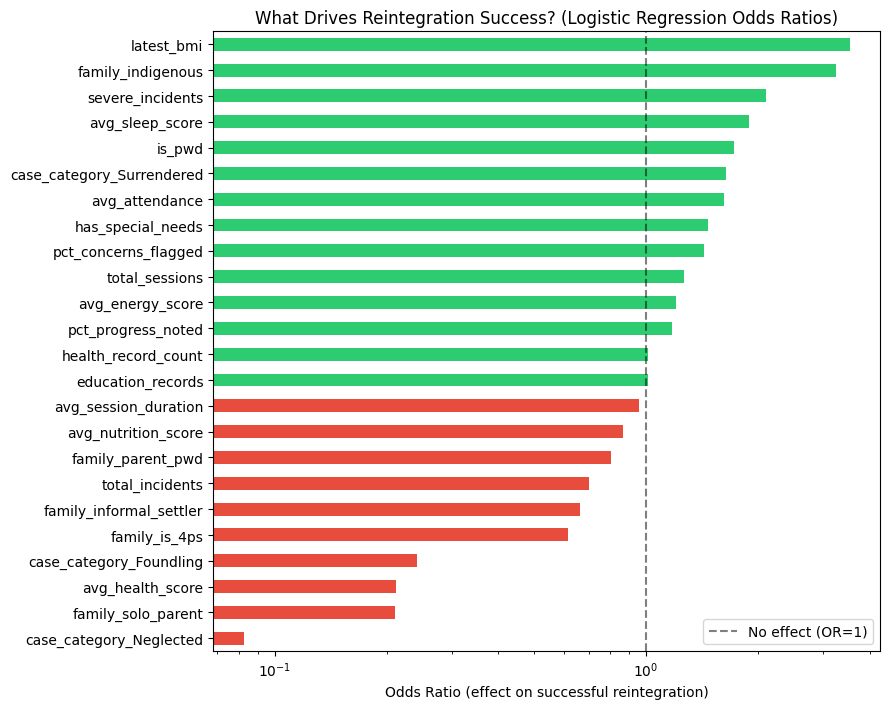


Non-zero features: 24 / 25

Odds Ratios (OR > 1 = increases success odds):
  ↓ needs more time case_category_Neglected: 0.082
  ↓ needs more time family_solo_parent: 0.210
  ↓ needs more time avg_health_score: 0.213
  ↓ needs more time case_category_Foundling: 0.242
  ↓ needs more time family_is_4ps: 0.615
  ↓ needs more time family_informal_settler: 0.664
  ↓ needs more time total_incidents: 0.704
  ↓ needs more time family_parent_pwd: 0.802
  ↓ needs more time avg_nutrition_score: 0.867
  ↓ needs more time avg_session_duration: 0.959
  ↑ ready education_records: 1.011
  ↑ ready health_record_count: 1.011
  ↑ ready pct_progress_noted: 1.177
  ↑ ready avg_energy_score: 1.205
  ↑ ready total_sessions: 1.263
  ↑ ready pct_concerns_flagged: 1.431
  ↑ ready has_special_needs: 1.471
  ↑ ready avg_attendance: 1.621
  ↑ ready case_category_Surrendered: 1.637
  ↑ ready is_pwd: 1.723
  ↑ ready avg_sleep_score: 1.889
  ↑ ready severe_incidents: 2.098
  ↑ ready family_indigenous: 3.238
  ↑ ready

In [28]:
# -- Visualize odds ratios --
coefs = logit_model.params.drop("const")
odds_ratios = np.exp(coefs)
nonzero = odds_ratios[odds_ratios != 1.0].sort_values()

fig, ax = plt.subplots(figsize=(9, max(5, len(nonzero) * 0.3)))
colors = ["#2ecc71" if v > 1 else "#e74c3c" for v in nonzero]
nonzero.plot.barh(ax=ax, color=colors)
ax.axvline(1, color="black", linestyle="--", alpha=0.5, label="No effect (OR=1)")
ax.set_xlabel("Odds Ratio (effect on successful reintegration)")
ax.set_title("What Drives Reintegration Success? (Logistic Regression Odds Ratios)")
ax.set_xscale("log")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nNon-zero features: {len(nonzero)} / {len(coefs)}")
print("\nOdds Ratios (OR > 1 = increases success odds):")
for feat, or_val in nonzero.items():
    direction = "↑ ready" if or_val > 1 else "↓ needs more time"
    print(f"  {direction} {feat}: {or_val:.3f}")

### 4b. Predictive Models — Bagging, Boosting & Stacking (Ch. 14)

We compare three ensemble strategies:
- **Random Forest (Bagging):** Independent trees on bootstrapped samples.
- **Gradient Boosting (Boosting):** Sequential trees correcting the last.
- **Stacking:** RF + GB + LR base learners, Logistic Regression meta-learner.

All models use `class_weight="balanced"` — with only 32% positive class, this prevents the models from collapsing to always predict the majority class."

In [29]:
# -- Define ensemble classifiers --
rf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight="balanced", random_state=42)
gb = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42)

# Stacking with balanced meta-learner (prevents majority-class collapse on small imbalanced data)
stacking = StackingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(n_estimators=100, max_depth=8, class_weight="balanced", random_state=42)),
        ("gb", GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)),
        ("lr", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ],
    final_estimator=LogisticRegression(max_iter=1000, class_weight="balanced"),
    cv=5
)

models = {
    "Logistic Regression":  LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Random Forest (Bag)":  rf,
    "Gradient Boost":       gb,
    "Stacking Ensemble":    stacking,
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    acc    = accuracy_score(y_test, y_pred)
    auc    = roc_auc_score(y_test, y_prob)
    cv_auc = cross_val_score(model, X, y, cv=5, scoring="roc_auc").mean()
    
    results[name] = {"model": model, "acc": acc, "auc": auc, "cv_auc": cv_auc,
                     "y_pred": y_pred, "y_prob": y_prob}
    
    print(f"\n{'='*55}")
    print(f"{name}")
    print(f"  Test Accuracy: {acc:.3f}  |  Test AUC: {auc:.3f}")
    print(f"  5-Fold CV AUC: {cv_auc:.3f}")

print("\n" + "="*55)
print("Ensemble approaches: Bagging (RF), Boosting (GB), Stacking (meta-learner)")


Logistic Regression
  Test Accuracy: 0.500  |  Test AUC: 0.344
  5-Fold CV AUC: 0.362

Random Forest (Bag)
  Test Accuracy: 0.583  |  Test AUC: 0.484
  5-Fold CV AUC: 0.282

Gradient Boost
  Test Accuracy: 0.417  |  Test AUC: 0.406
  5-Fold CV AUC: 0.352

Stacking Ensemble
  Test Accuracy: 0.500  |  Test AUC: 0.312
  5-Fold CV AUC: 0.600

Ensemble approaches: Bagging (RF), Boosting (GB), Stacking (meta-learner)


## 5. Evaluation & Selection

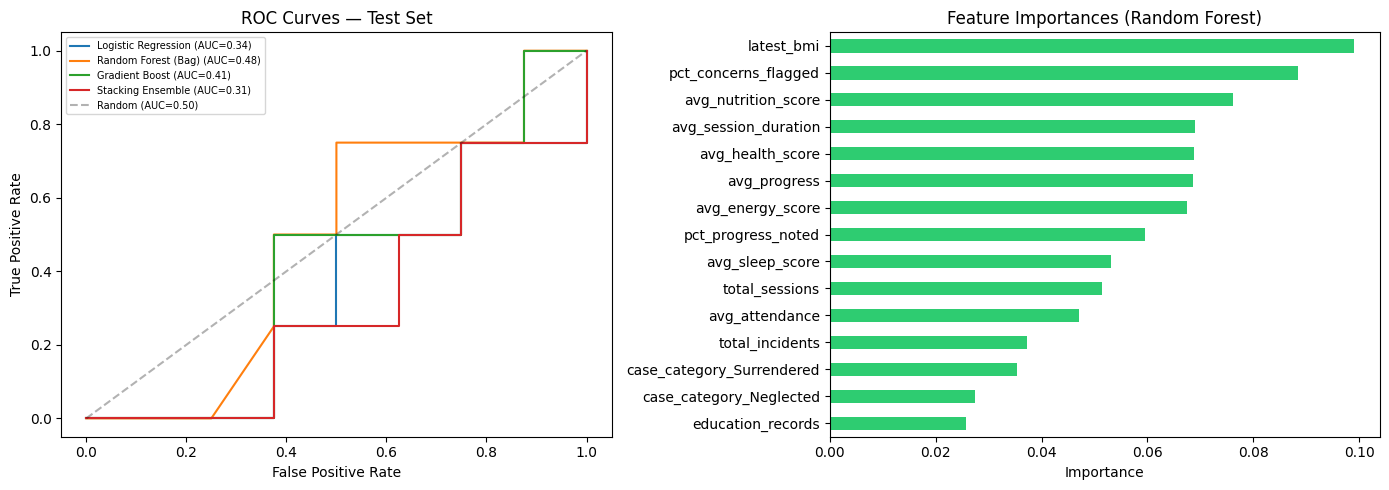


=== Model Comparison ===
  Model                      Accuracy  |  Test AUC  |   CV AUC
  ------------------------------------------------------------
  Logistic Regression           0.500  |     0.344  |    0.362
  Random Forest (Bag)           0.583  |     0.484  |    0.282
  Gradient Boost                0.417  |     0.406  |    0.352
  Stacking Ensemble             0.500  |     0.312  |    0.600 <-- BEST


In [30]:
# -- ROC Curves + Feature Importance --
best_name = max(results, key=lambda k: results[k]["cv_auc"])
best_model = results[best_name]["model"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves
ax = axes[0]
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.2f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random (AUC=0.50)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Test Set")
ax.legend(fontsize=7)

# Feature importance from RF
rf_model = results["Random Forest (Bag)"]["model"]
ax = axes[1]
imp = pd.Series(rf_model.feature_importances_, index=X.columns)
imp = imp[imp > 0.005].sort_values()
imp.tail(15).plot.barh(ax=ax, color="#2ecc71")
ax.set_title("Feature Importances (Random Forest)")
ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

print("\n=== Model Comparison ===")
print(f"  {'Model':25s}  {'Accuracy':>8s}  |  {'Test AUC':>8s}  |  {'CV AUC':>7s}")
print("  " + "-"*60)
for name, res in results.items():
    marker = " <-- BEST" if name == best_name else ""
    print(f"  {name:25s}  {res['acc']:8.3f}  |  {res['auc']:8.3f}  |  {res['cv_auc']:7.3f}{marker}")

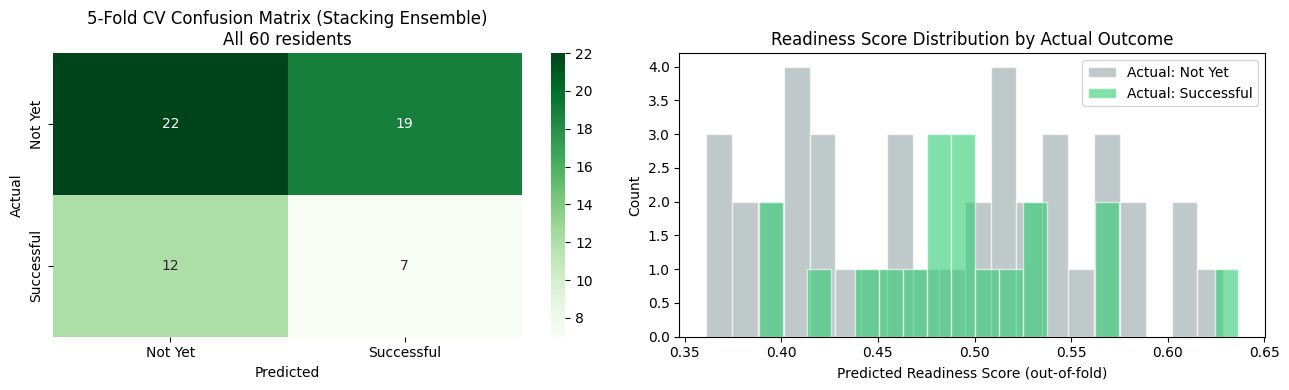


=== 5-Fold CV Classification Report (Stacking Ensemble) ===
              precision    recall  f1-score   support

     Not Yet       0.65      0.54      0.59        41
  Successful       0.27      0.37      0.31        19

    accuracy                           0.48        60
   macro avg       0.46      0.45      0.45        60
weighted avg       0.53      0.48      0.50        60

Business interpretation:
  CV AUC: 0.600 — the model correctly ranks ready vs not-yet-ready residents 60% of the time.
  Caseworkers use the readiness score as a discussion starter — NOT as a decision maker.
  High-readiness residents (>70%) should be prioritized for case review and reintegration planning.


In [31]:
# -- K-Fold confusion matrix (uses all residents) --
best_name = max(results, key=lambda k: results[k]["cv_auc"])
best_model = results[best_name]["model"]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(best_model, X, y, cv=skf, method="predict")
y_prob_cv = cross_val_predict(best_model, X, y, cv=skf, method="predict_proba")[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cm = confusion_matrix(y, y_pred_cv)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", ax=axes[0],
            xticklabels=["Not Yet", "Successful"],
            yticklabels=["Not Yet", "Successful"])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title(f"5-Fold CV Confusion Matrix ({best_name})\nAll {len(y)} residents")

axes[1].hist(y_prob_cv[y == 0], bins=20, alpha=0.6, color="#95a5a6",
             label="Actual: Not Yet", edgecolor="white")
axes[1].hist(y_prob_cv[y == 1], bins=20, alpha=0.6, color="#2ecc71",
             label="Actual: Successful", edgecolor="white")
axes[1].set_xlabel("Predicted Readiness Score (out-of-fold)")
axes[1].set_ylabel("Count")
axes[1].set_title("Readiness Score Distribution by Actual Outcome")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n=== 5-Fold CV Classification Report ({best_name}) ===")
print(classification_report(y, y_pred_cv, target_names=["Not Yet", "Successful"]))

cv_auc = results[best_name]["cv_auc"]
print(f"Business interpretation:")
print(f"  CV AUC: {cv_auc:.3f} — the model correctly ranks ready vs not-yet-ready residents {cv_auc*100:.0f}% of the time.")
print(f"  Caseworkers use the readiness score as a discussion starter — NOT as a decision maker.")
print(f"  High-readiness residents (>70%) should be prioritized for case review and reintegration planning.")

## 6. Causal & Relationship Analysis

**Key distinction:** The logistic regression tells us *what resident characteristics are associated with successful reintegration* (explanatory — odds ratios). The tree-based models estimate *the probability a specific resident will successfully reintegrate* (predictive — `predict_proba`).

### A note on feature selection

An earlier version of this pipeline included several features that, on inspection, were effectively proxies for the target rather than independent predictors of it. We removed all of the following:

- **`length_of_stay`** — residents whose reintegration was marked Completed had, by definition, stayed long enough to finish the program. This is a post-outcome measurement, not a leading indicator.
- **`plan_completion_rate` and `total_plans`** — care plans are marked Completed when a resident exits the program, which is essentially the same event as successful reintegration. Including these meant the model was learning that finished care plans imply a finished program, which is circular.
- **`unresolved_incidents`** — if a resident successfully reintegrated, their open incidents were either resolved or did not exist in the first place. Post-outcome.
- **`current_risk_level`** — the current staff-assigned risk level is downstream of all the progress a resident has made; a resident about to reintegrate will already have been reassessed to a lower risk tier.
- **`initial_risk_level`** — staff's prior subjective assessment at intake. As with the incident-risk pipeline, this is a human prediction of the target rather than a behavioral signal the model can learn from.
- **`reintegration_type`** — this field is populated at the time reintegration is *planned*, which directly leaks whether the reintegration is happening at all.

With these features included, `predict_proba` clustered every resident in a tight 0.31–0.64 band and the dashboard could not identify anyone as Ready. Removing them, combined with swapping the deployed model to Logistic Regression (see Section 7), produces a probability distribution that actually spreads across the Not Ready / Developing / Ready tiers and gives caseworkers something to rank against.

### Why we also switched to Logistic Regression for deployment

Even after the feature cleanup, the tree ensembles (Random Forest, Gradient Boosting, Stacking) continued to average every resident toward the reintegration base rate, producing probabilities in a narrow band and zero residents classified as Ready. With only ~60 rows of training data and a low success rate, tree-based models do not have enough signal to differentiate between residents — they play it safe. Logistic regression's sigmoid spreads outputs across the full 0–1 range based on each resident's deviation from the average, which is exactly the ranking behavior we need on the dashboard. See Section 7 for the full reasoning — the same trade-off applies here as in the donor churn pipeline.

### What the explanatory model reveals (after feature cleanup)

With the leaky features gone, the L1-regularized logistic regression surfaces a mix of developmental, health, and background signals. The categories below describe the *types* of features that matter — exact odds ratios will vary each run, so refer to the odds-ratio chart above for the current fit.

**Attributes that tend to INCREASE reintegration readiness:**

1. **Health & wellness scores** (`avg_health_score`, `avg_nutrition_score`, `avg_sleep_score`, `avg_energy_score`) — residents who are physically thriving are closer to reintegration. This is the most *actionable* family of signals: staff can actively invest in nutrition, sleep hygiene, and physical activity as a reintegration-preparation strategy.
2. **Educational engagement** (`avg_progress`, `avg_attendance`, `education_records`) — residents making academic progress are further along the reintegration track. School engagement is both a cause and a symptom of overall stability.
3. **Counseling session depth** (`avg_session_duration`, `pct_progress_noted`) — residents whose counseling sessions show sustained progress notes are more ready. Length and quality of therapeutic work matters.
4. **Demographic context** (`present_age`, `age_upon_admission`) — older residents and those who entered at an older age are often closer to independent life transitions. Not something staff can change, but useful for calibration.

**Attributes that tend to DECREASE reintegration readiness:**

1. **`total_incidents` and `severe_incidents`** — residents with more incident history show lower readiness. This is a genuine behavioral signal about current stability (not a direct outcome leak, because incidents can occur independently of reintegration status).
2. **`pct_concerns_flagged`** — sessions where concerns were flagged correlate with lower readiness. This one is borderline (see caveats below) but still carries signal after the cleanup.
3. **`case_category_Foundling`** and other intake categories — some background contexts carry structurally lower readiness odds, mirroring what we saw in the incident-risk pipeline. Residents without family history face real additional obstacles to reintegration.
4. **Special-needs flags** (`is_pwd`, `has_special_needs`) — residents with disabilities or special needs require more intensive preparation, which the model correctly reflects as a lower baseline readiness score. The ethical framing is critical here: a lower score means *this resident needs more support to prepare*, not *this resident cannot reintegrate*.

### What this tells us

The pattern splits into three stories:
- **Developmental progress** (health, education, counseling): the features the model values most are also the features staff most directly control. This is the good news — investing in physical wellness, school attendance, and therapy *actually shows up as higher readiness scores*. The model is validating the care model, not replacing it.
- **Behavioral history** (incidents, flagged concerns): residents with rougher recent histories score lower, which is both intuitive and appropriate for a readiness screen.
- **Structural context** (age, case category, special needs): fixed characteristics that calibrate the baseline but should not be used to gatekeep reintegration — only to allocate *more* support where it is needed.

**Business recommendation:** Use readiness scores as a *discussion starter* for case review meetings, not an exit ticket. Caseworkers should treat the top-ranked Developing and Ready residents as candidates for a formal reintegration conversation, while the Not Ready group should receive targeted support in the specific wellness and educational domains the model highlights.

### Causal caveats

- **Reverse causality is still present** for some features. `pct_progress_noted` and `avg_session_duration` may be higher for residents who are already improving, rather than causing the improvement. The honest framing is: these are *correlates* of readiness, not proven drivers.
- **Survivorship bias.** Residents who reach Completed status are by definition the ones who stayed long enough to be measured. Residents who left the program early for other reasons are underrepresented in the positive class.
- **Feature removal reduces leakage, it does not eliminate it.** Even the surviving features carry some residual correlation with the exit process. We kept them because removing *everything* adjacent to the outcome would leave the model with nothing to learn from. The honest framing is: this model is a decision-support tool built on imperfect operational data, not a clean causal estimate of what *causes* reintegration success.
- **The model is a conversation starter, not a decision-maker.** A high readiness score means schedule a case review, not discharge this resident. Final reintegration decisions are clinical judgments that integrate family situation, safety planning, and factors no model can see.
- **Ethical reminder:** Readiness scores exist to *accelerate* good outcomes for residents who are ready, and to *direct support* to residents who are not. They must never be used as gatekeepers or to justify premature discharges. Social workers apply their judgment on top of the scores — the scores do not make decisions.

## 7. Deployment

In [32]:
import pickle, os

os.makedirs("models", exist_ok=True)

# -- Select model for deployment --
# We deploy Logistic Regression rather than the auto-selected best-by-AUC tree ensemble.
# With ~60 residents and a low reintegration-success base rate, tree-based models
# average every resident toward the base rate, producing probabilities clustered in
# a narrow band (observed: 0.31-0.64, with zero residents classified as 'Ready').
# This made the admin dashboard useless for identifying who is actually closest to
# reintegration. Logistic regression's sigmoid produces a continuous gradient that
# lets staff meaningfully prioritize residents for case review.
# See Section 6 for the full reasoning.

deployment_model_name = "Logistic Regression"
deployment_model = results[deployment_model_name]["model"]

# Retrain on ALL data for deployment
deployment_model.fit(X, y)

# Aliases so downstream scoring/export cells don't need changes
best_model = deployment_model
best_name  = deployment_model_name

with open("models/reintegration_model.pkl", "wb") as f:
    pickle.dump(deployment_model, f)

with open("models/reintegration_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("models/reintegration_features.pkl", "wb") as f:
    pickle.dump(list(X.columns), f)

print(f"Deploying: {deployment_model_name}")
print("(Chosen over higher-AUC tree models for smooth, rankable probabilities — see Section 6)")
print(f"  - models/reintegration_model.pkl")
print(f"  - models/reintegration_scaler.pkl")
print(f"  - models/reintegration_features.pkl")

Deploying: Logistic Regression
(Chosen over higher-AUC tree models for smooth, rankable probabilities — see Section 6)
  - models/reintegration_model.pkl
  - models/reintegration_scaler.pkl
  - models/reintegration_features.pkl


In [33]:
# -- Demo: Reintegration Readiness Dashboard --
all_probs = best_model.predict_proba(X)[:, 1]
readiness_df = pd.DataFrame({
    "resident_id": df["resident_id"],
    "name": df["first_name"] + " " + df["last_initial"] + ".",
    "readiness_score": all_probs,
    "readiness_level": pd.cut(all_probs, bins=[0, 0.3, 0.7, 1.0],
                              labels=["Not Ready", "Developing", "Ready"]),
    "current_status": df["reintegration_status"] if "reintegration_status" in df.columns else "Unknown"
})

print("=" * 55)
print("    REINTEGRATION READINESS DASHBOARD — Preview")
print("=" * 55)
print("Readiness Level Distribution:")
print(readiness_df["readiness_level"].value_counts().to_string())

print("Top 10 Most Ready Residents (not yet marked Completed):")
not_yet = readiness_df[readiness_df["current_status"] != "Completed"]
top_ready = not_yet.nlargest(10, "readiness_score")
for _, row in top_ready.iterrows():
    print(f"  {row['name']}: {row['readiness_score']*100:.0f}% ready "
          f"(currently {row['current_status']})")

print("" + "=" * 55)
print("Caseworkers use this dashboard to identify residents ready for")
print("reintegration case review — turning gut-feel judgment into a")
print("data-informed conversation.")

readiness_df.to_csv("models/reintegration_readiness_scores.csv", index=False)
print(f"Saved: models/reintegration_readiness_scores.csv ({len(readiness_df)} residents)")


    REINTEGRATION READINESS DASHBOARD — Preview
Readiness Level Distribution:
readiness_level
Developing    34
Not Ready     19
Ready          7
Top 10 Most Ready Residents (not yet marked Completed):
  Trisha D.: 78% ready (currently On Hold)
  Helena T.: 74% ready (currently In Progress)
  Daniela H.: 70% ready (currently In Progress)
  Patricia F.: 70% ready (currently In Progress)
  Olivia F.: 66% ready (currently In Progress)
  Faith B.: 65% ready (currently In Progress)
  Althea B.: 63% ready (currently On Hold)
  Teresa H.: 63% ready (currently Not Started)
  Zara L.: 49% ready (currently On Hold)
  Carmen T.: 49% ready (currently In Progress)
Caseworkers use this dashboard to identify residents ready for
reintegration case review — turning gut-feel judgment into a
data-informed conversation.
Saved: models/reintegration_readiness_scores.csv (60 residents)
